# Bài tập thực hành chính quy: Xử lý ảnh và thị giác máy tính

Notebook này là học liệu hướng dẫn và khung làm bài cho hai chủ đề:

1. Hình thái học toán học.
2. Biến đổi hình học và chống răng cưa (anti-aliasing).

Phiên bản này yêu cầu sinh viên **tự viết nhiều thành phần nền tảng**, thay vì chỉ gọi các hàm trợ giúp có sẵn. Mục tiêu là buộc sinh viên hiểu bản chất của phép toán thay vì chỉ quan sát đầu ra.


# Thiết lập chung


In [34]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    cv2 = None

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'gray'


In [35]:
def show_image(img, title='', cmap='gray'):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_images(images, titles=None, cols=3, cmap='gray', figsize=(14, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# Ảnh kiểm thử


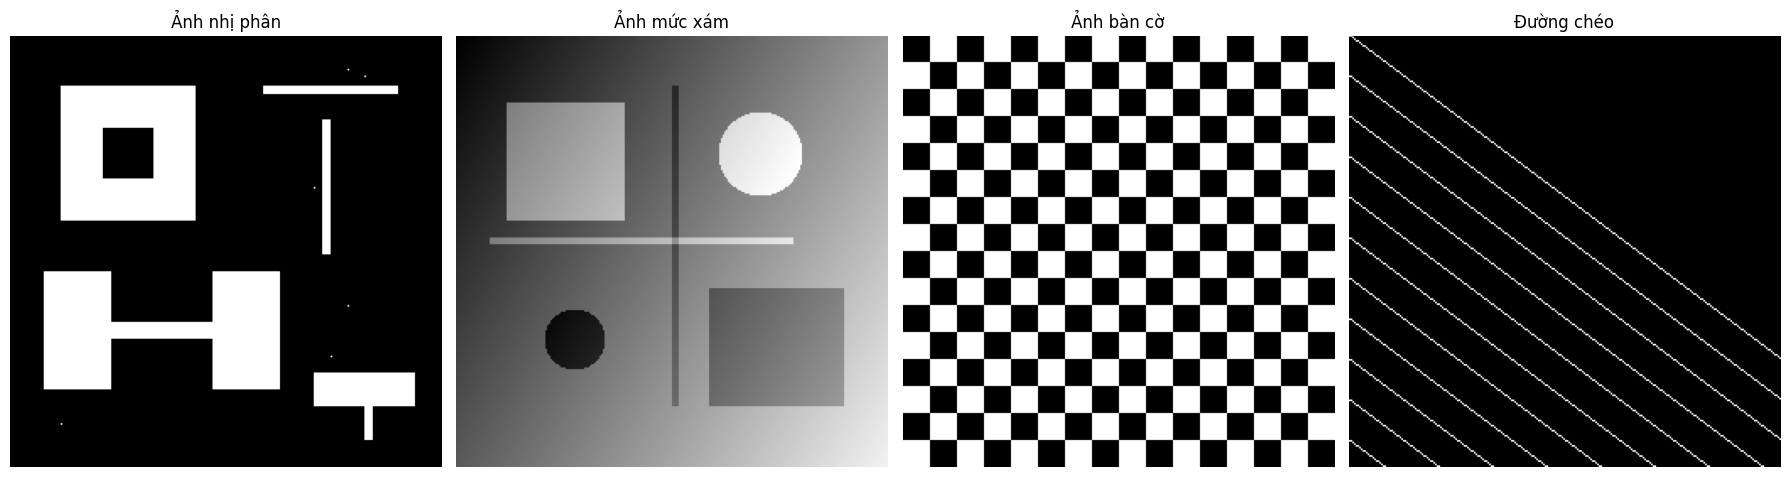

In [36]:
import numpy as np

def make_binary_test_image(size=256):
    img = np.zeros((size, size), dtype=np.uint8)
    img[30:110, 30:110] = 255
    img[55:85, 55:85] = 0
    img[140:210, 20:60] = 255
    img[170:180, 60:120] = 255
    img[140:210, 120:160] = 255
    img[30:35, 150:230] = 255
    img[50:130, 185:190] = 255
    img[200:220, 180:240] = 255
    img[220:240, 210:215] = 255
    noise_points = [(20, 200), (24, 210), (90, 180), (160, 200), (190, 190), (230, 30)]
    for r, c in noise_points:
        img[r, c] = 255
    return img


def make_grayscale_test_image(size=256):
    y, x = np.mgrid[0:size, 0:size]
    base = 40 + 0.5 * x + 0.3 * y
    img = base.astype(np.float32)
    img[40:110, 30:100] += 80
    img[150:220, 150:230] -= 50
    rr = (x - 180) ** 2 + (y - 70) ** 2
    img[rr < 25**2] += 90
    img[(x - 70) ** 2 + (y - 180) ** 2 < 18**2] -= 70
    img[120:124, 20:200] += 60
    img[30:220, 128:132] -= 40
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)


def make_checkerboard(size=256, block=16):
    y, x = np.indices((size, size))
    board = ((x // block + y // block) % 2) * 255
    return board.astype(np.uint8)


def make_diagonal_lines(size=256):
    """Ảnh với nhiều đường chéo mảnh -- đặc biệt nhạy cảm với răng cưa."""
    img = np.zeros((size, size), dtype=np.uint8)
    for k in range(0, size, 24):
        for t in range(size):
            r = k + t * 3 // 4
            c = t
            if 0 <= r < size:
                img[r, c] = 255
    return img


binary_img = make_binary_test_image()
grayscale_img = make_grayscale_test_image()
checkerboard_img = make_checkerboard()
diagonal_img = make_diagonal_lines()

show_images(
    [binary_img, grayscale_img, checkerboard_img, diagonal_img],
    titles=['Ảnh nhị phân', 'Ảnh mức xám', 'Ảnh bàn cờ', 'Đường chéo'],
    cols=4,
    figsize=(18, 5)
)

# Bài tập 1: Hình thái học toán học

## Yêu cầu trọng tâm

Sinh viên phải tự viết:

- hàm tạo phần tử cấu trúc,
- hàm padding cho ảnh nhị phân,
- các phép erosion, dilation, opening, closing, gradient.

## Quy ước phần tử cấu trúc

Chỉ dùng ba họ:

- `rectangle`: gồm vuông, ngang, dọc,
- `cross`,
- `ellipse`.

Không dùng `diamond`.


## Việc sinh viên phải làm

1. Tự cài đặt hàm sinh phần tử cấu trúc theo kích thước bất kỳ hợp lệ.
2. Với `rectangle`, phải hỗ trợ cả trường hợp vuông, chữ nhật ngang, chữ nhật dọc.
3. Tự cài đặt padding cho ảnh nhị phân.
4. Tự cài đặt erosion, dilation, opening, closing, gradient.
5. Thử trên ảnh nhị phân kiểm thử và ảnh mẫu giảng viên cung cấp.


In [37]:
# TODO: Sinh viên tự viết hàm padding cho ảnh nhị phân

def pad_binary_image_manual(img, pad_h, pad_w, mode='constant'):
    """
    Padding cho ảnh nhị phân.
    
    Tham số:
    - img: ảnh nhị phân (numpy array)
    - pad_h: padding theo chiều cao (top, bottom)
    - pad_w: padding theo chiều rộng (left, right)
    - mode: 'constant' (điền 0) hoặc 'edge' (lặp giá trị biên)
    
    Trả về: ảnh đã padding
    """
    if mode == 'constant':
        # Điền 0 (đen) quanh ảnh
        padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    elif mode == 'edge':
        # Lặp giá trị biên
        padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    else:
        raise ValueError(f"mode='{mode}' không được hỗ trợ. Chỉ hỗ trợ 'constant' hoặc 'edge'.")
    
    return padded

In [38]:
# TODO: Sinh viên tự viết hàm tạo phần tử cấu trúc

def make_structuring_element(shape, ksize):
    """
    Tạo phần tử cấu trúc (structuring element) cho hình thái học.
    
    Tham số:
    - shape: 'rectangle', 'cross', hoặc 'ellipse'
    - ksize: tuple (height, width) kích thước phần tử cấu trúc
    
    Trả về: numpy array nhị phân (1 = phần tử cấu trúc, 0 = nền)
    """
    height, width = ksize
    se = np.zeros((height, width), dtype=np.uint8)
    
    if shape == 'rectangle':
        # Hình chữ nhật (bao gồm vuông, ngang, dọc)
        se[:, :] = 1
        
    elif shape == 'cross':
        # Hình chữ thập
        center_r, center_c = height // 2, width // 2
        se[center_r, :] = 1  # Hàng ngang qua tâm
        se[:, center_c] = 1  # Cột dọc qua tâm
        
    elif shape == 'ellipse':
        # Hình elip
        center_r, center_c = height // 2, width // 2
        # Tính bán kính theo hàng và cột
        a = (height - 1) / 2  # Bán kính theo hàng
        b = (width - 1) / 2   # Bán kính theo cột
        
        for r in range(height):
            for c in range(width):
                # Kiểm tra xem điểm có nằm trong elip không
                if ((r - center_r) / a) ** 2 + ((c - center_c) / b) ** 2 <= 1:
                    se[r, c] = 1
                    
    else:
        raise ValueError(f"shape='{shape}' không được hỗ trợ. Chỉ hỗ trợ 'rectangle', 'cross', 'ellipse'.")
    
    return se

In [39]:
# TODO: Sinh viên tự hoàn thiện các phép toán hình thái học

def erosion_binary(img, se):
    """
    Phép erosion (xói mòn) trên ảnh nhị phân.
    
    Một pixel được giữ nguyên (giá trị 255) nếu TẤT CẢ các pixel trong vùng
    được phần tử cấu trúc bao phủ đều có giá trị 255. Ngược lại, nó thành 0.
    
    Tham số:
    - img: ảnh nhị phân đầu vào
    - se: phần tử cấu trúc (structuring element)
    
    Trả về: ảnh sau erosion
    """
    se_h, se_w = se.shape
    pad_h = se_h // 2
    pad_w = se_w // 2
    
    # Padding ảnh
    padded = pad_binary_image_manual(img, pad_h, pad_w, mode='constant')
    
    # Ảnh kết quả
    H, W = img.shape
    result = np.zeros((H, W), dtype=np.uint8)
    
    # Duyệt từng pixel
    for r in range(H):
        for c in range(W):
            # Lấy vùng tương ứng với phần tử cấu trúc
            patch = padded[r:r+se_h, c:c+se_w]
            # Kiểm tra xem TẤT CẢ các pixel trong patch (nơi se=1) đều bằng 255
            if np.all(patch[se == 1] == 255):
                result[r, c] = 255
    
    return result


def dilation_binary(img, se):
    """
    Phép dilation (giãn nở) trên ảnh nhị phân.
    
    Một pixel được gán 255 nếu CÓ ÍT NHẤT MỘT pixel trong vùng được phần tử
    cấu trúc bao phủ có giá trị 255.
    
    Tham số:
    - img: ảnh nhị phân đầu vào
    - se: phần tử cấu trúc (structuring element)
    
    Trả về: ảnh sau dilation
    """
    se_h, se_w = se.shape
    pad_h = se_h // 2
    pad_w = se_w // 2
    
    # Padding ảnh
    padded = pad_binary_image_manual(img, pad_h, pad_w, mode='constant')
    
    # Ảnh kết quả
    H, W = img.shape
    result = np.zeros((H, W), dtype=np.uint8)
    
    # Duyệt từng pixel
    for r in range(H):
        for c in range(W):
            # Lấy vùng tương ứng với phần tử cấu trúc
            patch = padded[r:r+se_h, c:c+se_w]
            # Kiểm tra xem CÓ ÍT NHẤT MỘT pixel trong patch (nơi se=1) bằng 255
            if np.any(patch[se == 1] == 255):
                result[r, c] = 255
    
    return result


def opening_binary(img, se):
    """
    Phép opening = erosion theo sau dilation.
    
    Loại bỏ các vật thể nhỏ, ngắt kết nối các vùng.
    
    Tham số:
    - img: ảnh nhị phân đầu vào
    - se: phần tử cấu trúc
    
    Trả về: ảnh sau opening
    """
    eroded = erosion_binary(img, se)
    opened = dilation_binary(eroded, se)
    return opened


def closing_binary(img, se):
    """
    Phép closing = dilation theo sau erosion.
    
    Đóng các lỗ hổng nhỏ, nối các vùng gần nhau.
    
    Tham số:
    - img: ảnh nhị phân đầu vào
    - se: phần tử cấu trúc
    
    Trả về: ảnh sau closing
    """
    dilated = dilation_binary(img, se)
    closed = erosion_binary(dilated, se)
    return closed


def morphological_gradient_binary(img, se):
    """
    Gradient hình thái học = dilation - erosion.
    
    Làm nổi bật các biên của vật thể trong ảnh.
    
    Tham số:
    - img: ảnh nhị phân đầu vào
    - se: phần tử cấu trúc
    
    Trả về: ảnh gradient (các biên sáng)
    """
    dilated = dilation_binary(img, se)
    eroded = erosion_binary(img, se)
    gradient = dilated.astype(np.int16) - eroded.astype(np.int16)
    return gradient.astype(np.uint8)

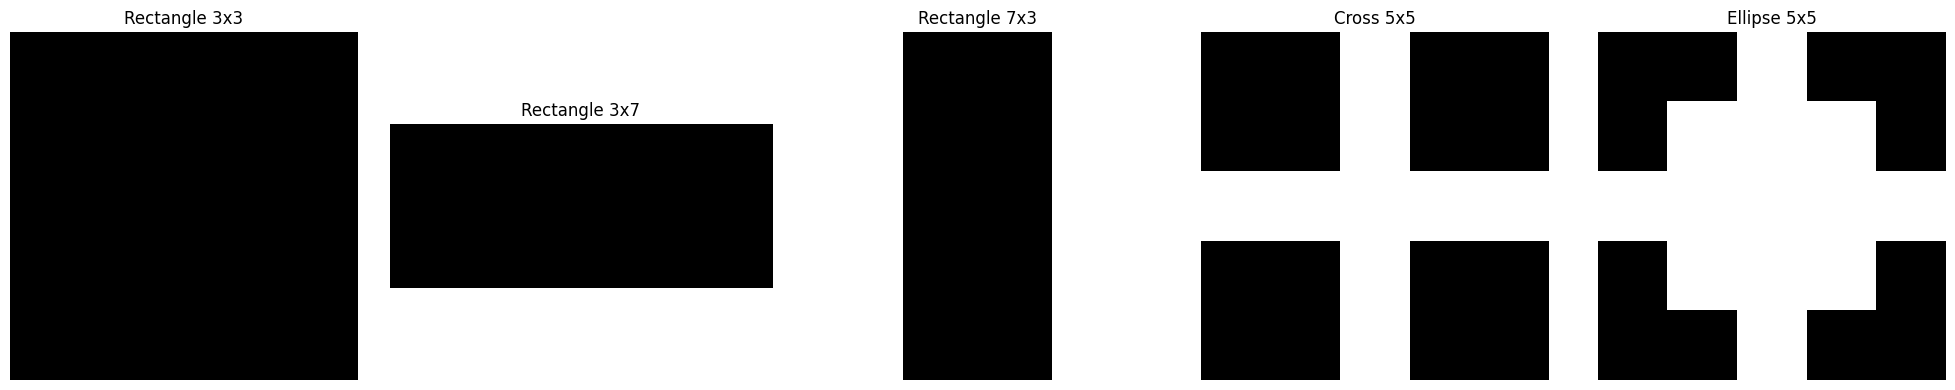

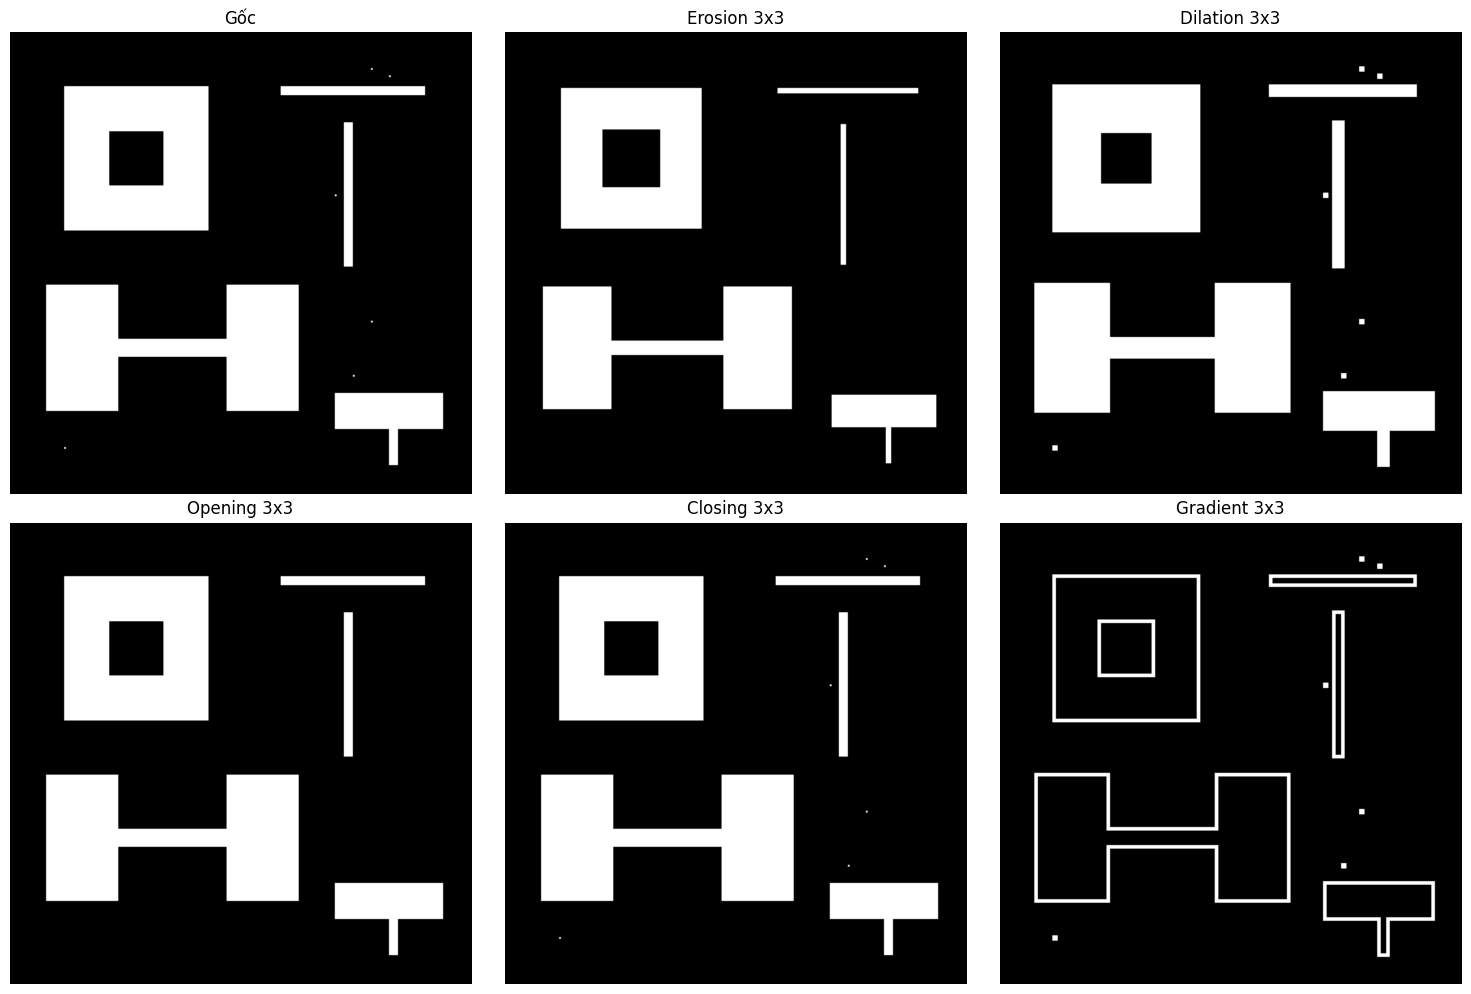

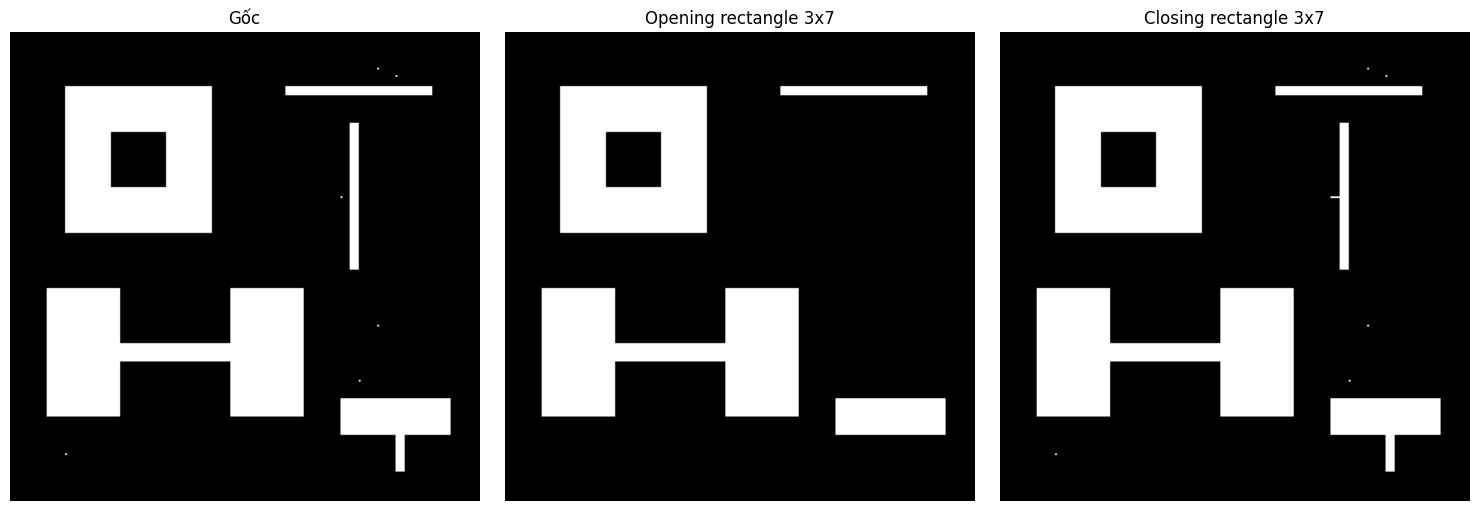

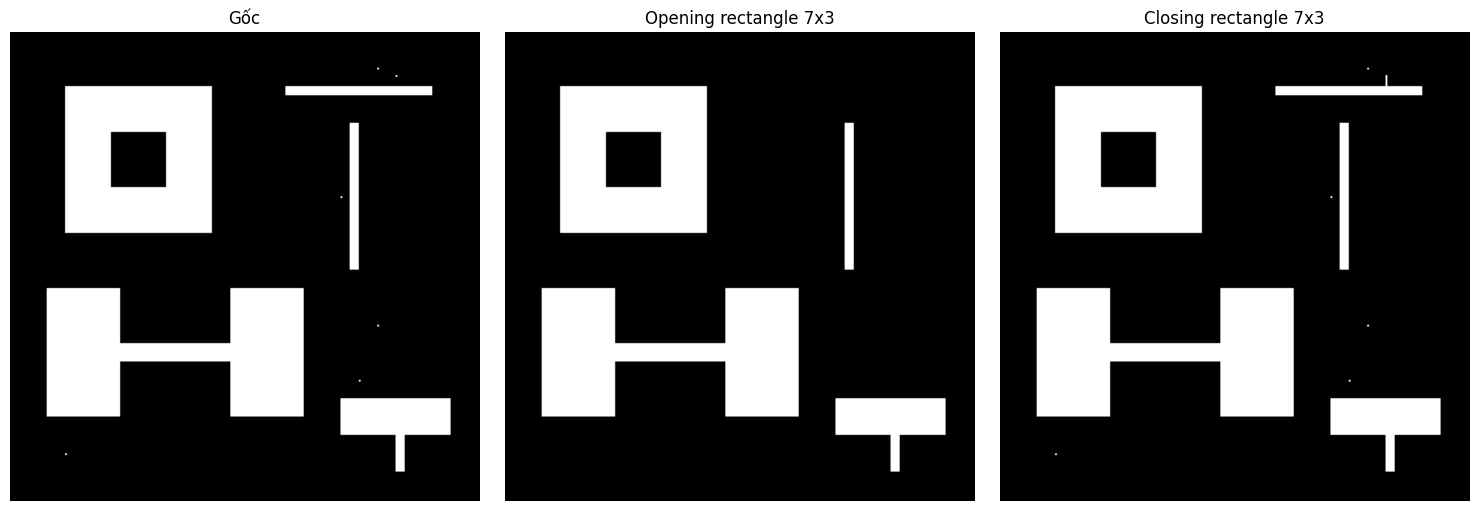

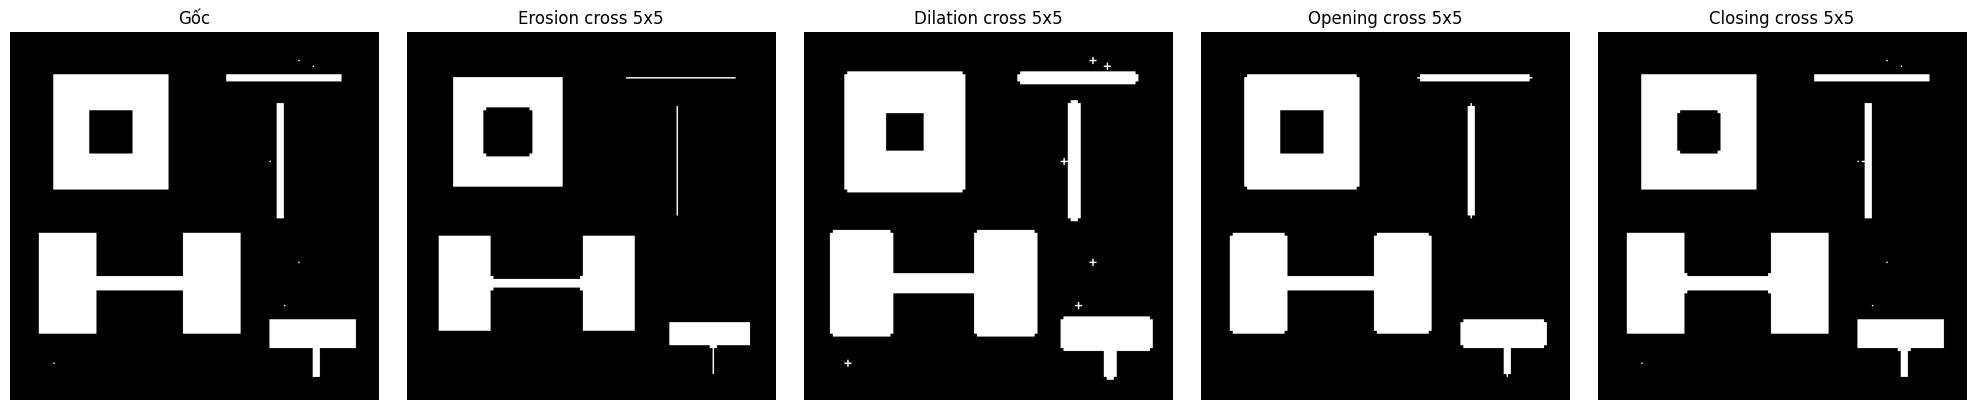

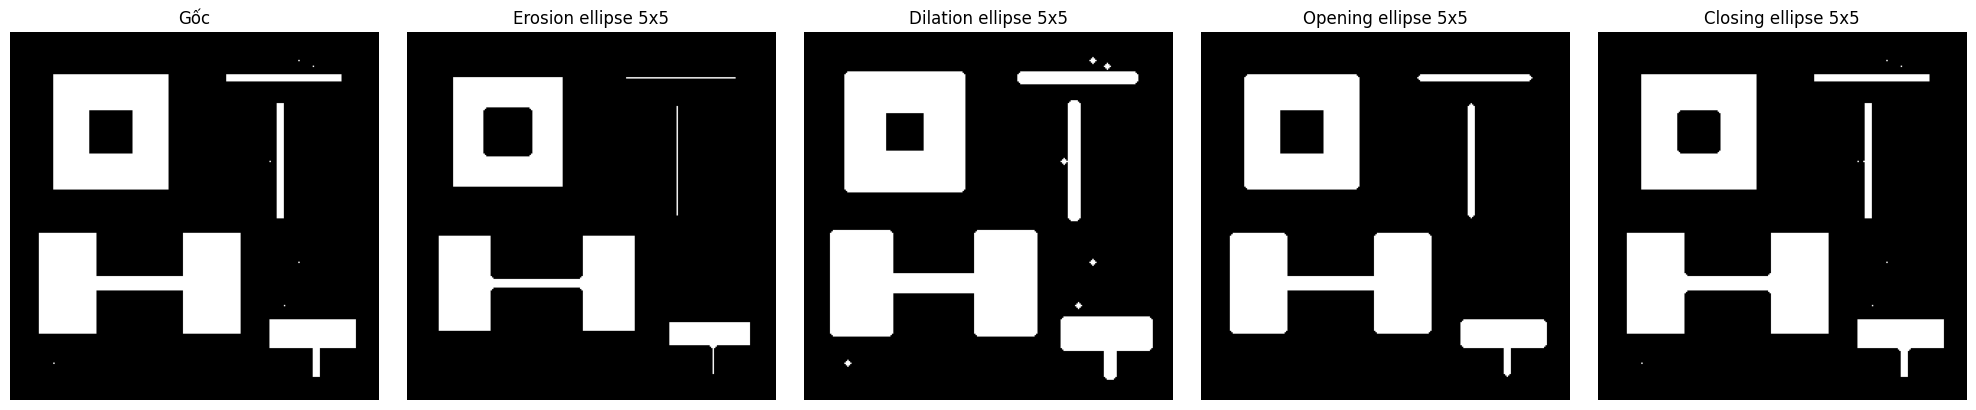

In [40]:
# Ô thực hành gợi ý
# Sau khi hoàn thiện các hàm ở trên, sinh viên tự chạy các thử nghiệm ở đây.

# Test với phần tử cấu trúc rectangle 3x3
se_rect_3x3 = make_structuring_element('rectangle', (3, 3))
se_rect_3x7 = make_structuring_element('rectangle', (3, 7))
se_rect_7x3 = make_structuring_element('rectangle', (7, 3))
se_cross_5x5 = make_structuring_element('cross', (5, 5))
se_ellipse_5x5 = make_structuring_element('ellipse', (5, 5))

# Hiển thị các phần tử cấu trúc
show_images(
    [se_rect_3x3, se_rect_3x7, se_rect_7x3, se_cross_5x5, se_ellipse_5x5],
    titles=['Rectangle 3x3', 'Rectangle 3x7', 'Rectangle 7x3', 'Cross 5x5', 'Ellipse 5x5'],
    cols=5,
    figsize=(20, 4)
)

# Test các phép toán với rectangle 3x3
eroded = erosion_binary(binary_img, se_rect_3x3)
dilated = dilation_binary(binary_img, se_rect_3x3)
opened = opening_binary(binary_img, se_rect_3x3)
closed = closing_binary(binary_img, se_rect_3x3)
gradient = morphological_gradient_binary(binary_img, se_rect_3x3)

show_images(
    [binary_img, eroded, dilated, opened, closed, gradient],
    titles=['Gốc', 'Erosion 3x3', 'Dilation 3x3', 'Opening 3x3', 'Closing 3x3', 'Gradient 3x3'],
    cols=3,
    figsize=(15, 10)
)

# Test với rectangle 3x7 (ngang)
opened_h = opening_binary(binary_img, se_rect_3x7)
closed_h = closing_binary(binary_img, se_rect_3x7)

show_images(
    [binary_img, opened_h, closed_h],
    titles=['Gốc', 'Opening rectangle 3x7', 'Closing rectangle 3x7'],
    cols=3,
    figsize=(15, 5)
)

# Test với rectangle 7x3 (dọc)
opened_v = opening_binary(binary_img, se_rect_7x3)
closed_v = closing_binary(binary_img, se_rect_7x3)

show_images(
    [binary_img, opened_v, closed_v],
    titles=['Gốc', 'Opening rectangle 7x3', 'Closing rectangle 7x3'],
    cols=3,
    figsize=(15, 5)
)

# Test với cross 5x5
eroded_cross = erosion_binary(binary_img, se_cross_5x5)
dilated_cross = dilation_binary(binary_img, se_cross_5x5)
opened_cross = opening_binary(binary_img, se_cross_5x5)
closed_cross = closing_binary(binary_img, se_cross_5x5)

show_images(
    [binary_img, eroded_cross, dilated_cross, opened_cross, closed_cross],
    titles=['Gốc', 'Erosion cross 5x5', 'Dilation cross 5x5', 'Opening cross 5x5', 'Closing cross 5x5'],
    cols=5,
    figsize=(20, 4)
)

# Test với ellipse 5x5
eroded_ellipse = erosion_binary(binary_img, se_ellipse_5x5)
dilated_ellipse = dilation_binary(binary_img, se_ellipse_5x5)
opened_ellipse = opening_binary(binary_img, se_ellipse_5x5)
closed_ellipse = closing_binary(binary_img, se_ellipse_5x5)

show_images(
    [binary_img, eroded_ellipse, dilated_ellipse, opened_ellipse, closed_ellipse],
    titles=['Gốc', 'Erosion ellipse 5x5', 'Dilation ellipse 5x5', 'Opening ellipse 5x5', 'Closing ellipse 5x5'],
    cols=5,
    figsize=(20, 4)
)

# Bài tập 2: Biến đổi hình học và Chống Răng Cưa

Bài tập này xây dựng toàn bộ pipeline biến đổi hình học có anti-aliasing.

## Phân biệt hai cơ chế cốt lõi

| Cơ chế | Kernel | Hàm dùng |
|---|---|---|
| **Tích chập** (`convolution`) | Cố định, không đổi theo vị trí | `convolve2d_manual` gọi **một lần** cho cả ảnh |
| **Tích vô hướng cục bộ** (`local dot product`) | Thay đổi theo $\delta_r, \delta_c$ của từng pixel | Tính **bên trong vòng lặp** của `warp_affine_manual` |

- **Nearest, Bilinear, SSAA** → kernel cố định hoặc không cần kernel → `convolve2d_manual` có thể dùng.
- **Bicubic, Lanczos** → kernel phụ thuộc vào phần lẻ $\delta$ của tọa độ nguồn → **không thể** gọi `convolve2d_manual` một lần toàn ảnh; phải tính cục bộ mỗi pixel.

## Việc sinh viên phải làm

1. Cài đặt ít nhất hai phép biến đổi affine (bắt buộc có quay và co giãn/shear).
2. Cài đặt `nearest_interpolate` và `bilinear_interpolate`.
3. **Tự viết** `convolve2d_manual` bằng vòng lặp (dùng cho SSAA và làm mượt sau warp).
4. Cài đặt `warp_affine_manual` dùng ánh xạ ngược.
5. Cài đặt `warp_affine_ssaa` dùng `convolve2d_manual` (tích chập cố định).
6. Cài đặt `bicubic_interpolate` và `lanczos_interpolate` (tích vô hướng cục bộ).
7. Tích hợp bicubic/Lanczos vào `warp_affine_manual` qua tham số `interpolation`.

## Ràng buộc

- Không dùng `cv2.warpAffine`, `scipy.ndimage.affine_transform`, `skimage.transform.warp`.
- Không dùng `scipy.signal.convolve2d`, `np.convolve` hay hàm tích chập có sẵn -- phải tự viết vòng lặp.
- Không chọn biến đổi quá tầm thường (quay 0°) làm ví dụ chính.


## Phần A -- Nội suy và tích chập nền tảng

### nearest_interpolate / bilinear_interpolate
**Cơ chế:** tích vô hướng cục bộ với cửa sổ cố định ($1\times1$ và $2\times2$).  
Kernel không phụ thuộc vào $\delta$ theo cách phức tạp -- bilinear dùng
$\mathbf{w}_r = [1-\delta_r, \delta_r]$ và $\mathbf{w}_c = [1-\delta_c, \delta_c]$,
tích ngoài cho ma trận $2\times2$.

### convolve2d_manual
**Cơ chế:** tích chập thực sự -- kernel **cố định**, trượt qua toàn ảnh.  
Dùng cho SSAA (kernel hộp $L\times L$) và làm mượt sau warp (kernel Gaussian).  
**Không phù hợp** cho Bicubic/Lanczos vì kernel của chúng thay đổi mỗi pixel.




In [41]:
def translation_matrix(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ], dtype=np.float32)


def scaling_matrix(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ], dtype=np.float32)


def rotation_matrix(deg):
    rad = np.deg2rad(deg)
    c, s = np.cos(rad), np.sin(rad)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ], dtype=np.float32)


def shear_matrix(shx=0.0, shy=0.0):
    return np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ], dtype=np.float32)


In [42]:
# TODO: Sinh viên tự hoàn thiện nội suy

def nearest_interpolate(img, x, y):
    """
    Nội suy nearest-neighbor tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng 1x1 -- chọn pixel nguyên gần nhất.
    Không phụ thuộc vào delta; không cần xây kernel.

    Trả về: float, giá trị tại pixel gần nhất.
    """
    H, W = img.shape
    # Làm tròn về số nguyên gần nhất
    x_int = int(round(x))
    y_int = int(round(y))
    
    # Kiểm tra biên
    if 0 <= x_int < W and 0 <= y_int < H:
        return float(img[y_int, x_int])
    else:
        return 0.0  # Giá trị mặc định nếu ngoài biên


def bilinear_interpolate(img, x, y):
    """
    Nội suy bilinear tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ 2x2.
    - delta_c = x - floor(x),  delta_r = y - floor(y)
    - w_c = [1-delta_c, delta_c]  (vector hàng)
    - w_r = [1-delta_r, delta_r]  (vector cột)
    - Patch P = I[floor(y):floor(y)+2, floor(x):floor(x)+2]
    - Kết quả = w_r @ P @ w_c  (tích vô hướng, KHÔNG phải tích chập)

    Trả về: float, clamp về [0, 255].
    """
    H, W = img.shape
    
    # Lấy tọa độ nguyên
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    x1 = x0 + 1
    y1 = y0 + 1
    
    # Tính delta
    delta_c = x - x0
    delta_r = y - y0
    
    # Trọng số
    w_c = np.array([1 - delta_c, delta_c])
    w_r = np.array([1 - delta_r, delta_r])
    
    # Lấy patch 2x2
    # Xử lý biên bằng cách clamp
    y0_clamp = max(0, min(H - 1, y0))
    y1_clamp = max(0, min(H - 1, y1))
    x0_clamp = max(0, min(W - 1, x0))
    x1_clamp = max(0, min(W - 1, x1))
    
    patch = np.array([
        [img[y0_clamp, x0_clamp], img[y0_clamp, x1_clamp]],
        [img[y1_clamp, x0_clamp], img[y1_clamp, x1_clamp]]
    ], dtype=np.float32)
    
    # Tích vô hướng
    result = w_r @ patch @ w_c
    
    # Clamp về [0, 255]
    return float(np.clip(result, 0, 255))

In [43]:
# TODO: Sinh viên tự viết tích chập 2D bằng vòng lặp
# Không được dùng bất kỳ hàm tích chập có sẵn nào.

def convolve2d_manual(img, kernel, pad_mode='constant', pad_value=0):
    """
    Tích chập 2D thủ công -- kernel CỐ ĐỊNH, trượt qua toàn ảnh.

    Dùng cho:
      - SSAA: kernel = np.ones((L,L))/L**2  (box filter)
      - Làm mượt sau warp: kernel = gaussian_kernel(n)
    KHÔNG dùng cho Bicubic/Lanczos (kernel của chúng thay đổi theo delta).

    Tham số
    -------
    img       : np.ndarray (H, W), kiểu float
    kernel    : np.ndarray (kH, kW)  -- cố định, không phụ thuộc vào vị trí
    pad_mode  : 'constant' -- điền pad_value ngoài biên
    pad_value : giá trị điền khi pad_mode='constant'

    Trả về
    ------
    out : np.ndarray (H, W), cùng kiểu với img

    Gợi ý các bước
    --------------
    1. Lật kernel 180° (flip cả hàng lẫn cột) -- đây là điểm khác biệt
       giữa convolution và cross-correlation.
    2. Pad ảnh đầu vào đủ để giữ nguyên kích thước đầu ra.
    3. Duyệt từng pixel (r, c), tính tổng trọng số cửa sổ kernel.
    """
    H, W = img.shape
    kH, kW = kernel.shape
    
    # Lật kernel 180 độ (convolution vs cross-correlation)
    kernel_flipped = np.flip(kernel)
    
    # Padding
    pad_h = kH // 2
    pad_w = kW // 2
    
    if pad_mode == 'constant':
        padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), 
                       mode='constant', constant_values=pad_value)
    else:
        padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode=pad_mode)
    
    # Ảnh kết quả
    out = np.zeros((H, W), dtype=img.dtype)
    
    # Duyệt từng pixel
    for r in range(H):
        for c in range(W):
            # Lấy cửa sổ tương ứng
            window = padded[r:r+kH, c:c+kW]
            # Tính tích chập
            out[r, c] = np.sum(window * kernel_flipped)
    
    return out

In [44]:
# TODO: Sinh viên tự hoàn thiện warp affine bằng ánh xạ ngược

def warp_affine_manual(img, matrix, out_shape, interpolation='nearest', fill_value=0):
    """
    Biến đổi affine dùng ánh xạ ngược.

    Pipeline cho mỗi pixel đích (r', c'):
      [x, y, 1]^T = matrix^{-1} @ [c', r', 1]^T
      if (x, y) ngoài biên: gán fill_value
      else: gọi hàm nội suy phù hợp

    Phân biệt cơ chế theo interpolation:
      'nearest'  -> nearest_interpolate(img, x, y)
                    [tích vô hướng 1x1, không cần delta]
      'bilinear' -> bilinear_interpolate(img, x, y)
                    [tích vô hướng 2x2, w = f(delta)]
      'bicubic'  -> bicubic_interpolate(img, x, y)
                    [tích vô hướng 4x4, kernel = R(delta-i) -- thay đổi mỗi pixel]
      'lanczos'  -> lanczos_interpolate(img, x, y)
                    [tích vô hướng (2a)x(2a), kernel = L(delta-i) -- thay đổi mỗi pixel]

    Lưu ý: SSAA dùng hàm riêng warp_affine_ssaa, không qua đây.

    interpolation : 'nearest' | 'bilinear' | 'bicubic' | 'lanczos'
    """
    H_out, W_out = out_shape
    H_in, W_in = img.shape
    
    # Ma trận nghịch đảo cho ánh xạ ngược
    inv_matrix = np.linalg.inv(matrix)
    
    # Ảnh kết quả
    out = np.zeros(out_shape, dtype=img.dtype)
    
    # Duyệt từng pixel đích
    for r_out in range(H_out):
        for c_out in range(W_out):
            # Tọa độ đồng nhất của pixel đích
            dst_homogeneous = np.array([c_out, r_out, 1])
            
            # Ánh xạ ngược về tọa độ nguồn
            src_homogeneous = inv_matrix @ dst_homogeneous
            x_src = src_homogeneous[0]
            y_src = src_homogeneous[1]
            
            # Kiểm tra xem tọa độ nguồn có trong ảnh không
            if 0 <= x_src < W_in and 0 <= y_src < H_in:
                # Gọi hàm nội suy phù hợp
                if interpolation == 'nearest':
                    out[r_out, c_out] = nearest_interpolate(img, x_src, y_src)
                elif interpolation == 'bilinear':
                    out[r_out, c_out] = bilinear_interpolate(img, x_src, y_src)
                elif interpolation == 'bicubic':
                    out[r_out, c_out] = bicubic_interpolate(img, x_src, y_src)
                elif interpolation == 'lanczos':
                    out[r_out, c_out] = lanczos_interpolate(img, x_src, y_src)
                else:
                    raise ValueError(f"interpolation='{interpolation}' không được hỗ trợ.")
            else:
                out[r_out, c_out] = fill_value
    
    return out

In [45]:
# Ô kiểm tra nhanh Phần A
# Ví dụ khung:
# M = rotation_matrix(25)
# out_nn = warp_affine_manual(checkerboard_img.astype(np.float32), M, checkerboard_img.shape, interpolation='nearest')
# out_bl = warp_affine_manual(checkerboard_img.astype(np.float32), M, checkerboard_img.shape, interpolation='bilinear')
# show_images([checkerboard_img, out_nn, out_bl], ['Đầu vào', 'Nearest', 'Bilinear'])


## Phần B -- Anti-aliasing qua nội suy nâng cao

Khi xoay hoặc phóng to ảnh, các đường chéo và cạnh cong trông gồ ghề
(răng cưa / jaggies). Nguyên nhân: tọa độ nguồn $(y, x)$ sau ánh xạ ngược
không trùng với lưới pixel -- phần lẻ $\delta$ khác nhau mỗi pixel đích.

### Hai cách chống răng cưa

**Cách 1 -- Tích chập cố định (SSAA):**  
Warp bằng nearest, rồi gọi `convolve2d_manual` với kernel hộp.  
Kernel không thay đổi → có thể dùng `convolve2d_manual` một lần.

**Cách 2 -- Tích vô hướng cục bộ với kernel thay đổi (Bicubic, Lanczos):**  
Bên trong vòng lặp của `warp_affine_manual`, mỗi pixel đích tính
$(\delta_r, \delta_c)$, xây weight vector $w_r, w_c$, rồi thực hiện
tích vô hướng với patch $4\times4$ hoặc $(2a)\times(2a)$.  
Kernel thay đổi mỗi pixel → **không thể** gọi `convolve2d_manual` toàn ảnh.


### Kỹ thuật 1: Supersampling Anti-Aliasing (SSAA) -- tích chập cố định

**Ý tưởng:** Lấy $L^2$ mẫu đều nhau trong diện tích pixel đích, mỗi mẫu
ánh xạ ngược về ảnh nguồn và nội suy bilinear, rồi trung bình.

$$C(r', c') = \frac{1}{L^2}\sum_{m=0}^{L-1}\sum_{n=0}^{L-1}
f\!\left(r'+\frac{m+0.5}{L},\;c'+\frac{n+0.5}{L}\right)$$

**Liên hệ với tích chập:** SSAA tương đương áp bộ lọc hộp $L\times L$
lên ảnh đã warp nearest. Kernel hộp **không phụ thuộc** vào $\delta$ --
nó như nhau tại mọi pixel:
$$K_{\text{box}}^{(L)} = \frac{1}{L^2}\mathbf{1}_{L\times L}$$

Vì vậy `warp_affine_ssaa` có thể được cài đặt theo một trong hai cách:
- **Cách A (khuyến khích):** warp nearest → `convolve2d_manual(warped, K_box)`.
- **Cách B:** vòng lặp $L^2$ mẫu mỗi pixel (theo công thức trên).

Cả hai cho cùng kết quả; Cách A tái sử dụng hàm đã viết.


In [46]:
# TODO: Sinh viên tự cài đặt SSAA

def warp_affine_ssaa(img, matrix, out_shape, L=2, fill_value=0):
    """
    Biến đổi affine với Supersampling Anti-Aliasing.

    Với mỗi pixel đích (r', c'), lấy L*L mẫu con đều nhau trong
    diện tích pixel, ánh xạ ngược từng mẫu con về ảnh nguồn,
    nội suy bilinear, rồi lấy trung bình.

    Gợi ý: offset mẫu con thứ (m, n) tại pixel (r', c') là
        (r' + (m + 0.5) / L,  c' + (n + 0.5) / L)
    trước khi ánh xạ ngược qua matrix^{-1}.

    L : int -- hệ số supersampling (L=2 => 4 mẫu/pixel, L=4 => 16 mẫu/pixel)
    """
    H_out, W_out = out_shape
    H_in, W_in = img.shape
    
    # Ma trận nghịch đảo cho ánh xạ ngược
    inv_matrix = np.linalg.inv(matrix)
    
    # Ảnh kết quả
    out = np.zeros(out_shape, dtype=img.dtype)
    
    # Duyệt từng pixel đích
    for r_out in range(H_out):
        for c_out in range(W_out):
            total = 0.0
            count = 0
            
            # Lấy L*L mẫu con trong pixel
            for m in range(L):
                for n in range(L):
                    # Offset mẫu con
                    r_sample = r_out + (m + 0.5) / L
                    c_sample = c_out + (n + 0.5) / L
                    
                    # Tọa độ đồng nhất của mẫu con
                    dst_homogeneous = np.array([c_sample, r_sample, 1])
                    
                    # Ánh xạ ngược về tọa độ nguồn
                    src_homogeneous = inv_matrix @ dst_homogeneous
                    x_src = src_homogeneous[0]
                    y_src = src_homogeneous[1]
                    
                    # Kiểm tra biên và nội suy bilinear
                    if 0 <= x_src < W_in and 0 <= y_src < H_in:
                        total += bilinear_interpolate(img, x_src, y_src)
                        count += 1
                    else:
                        total += fill_value
                        count += 1
            
            # Trung bình các mẫu
            out[r_out, c_out] = total / count
    
    return out

### Kỹ thuật 2: Bicubic -- tích vô hướng cục bộ $4\times4$

**Ý tưởng:** Dùng cửa sổ $4\times4$ pixel lân cận và hàm trọng số
cubic $R(d)$ (Keys) thay vì trung bình đều.

**Hàm trọng số 1D** ($a = -0.5$):
$$R(d) = \begin{cases}
(a+2)|d|^3 - (a+3)|d|^2 + 1 & |d| \leq 1 \\
a|d|^3 - 5a|d|^2 + 8a|d| - 4a & 1 < |d| < 2 \\
0 & \text{còn lại}
\end{cases}$$

**Tại sao không dùng `convolve2d_manual`?**  
Tại mỗi pixel đích, $\delta_r$ và $\delta_c$ khác nhau.  
Weight vector $\mathbf{w}_r = [R(\delta_r+1),\,R(\delta_r),\,R(\delta_r-1),\,R(\delta_r-2)]$
thay đổi theo $\delta_r$ -- kernel không cố định.  
Phải tính bên trong vòng lặp của `warp_affine_manual`.

**Công thức tích vô hướng cục bộ:**
$$P(y,x) = \mathbf{w}_r^T \cdot I_{\text{patch}} \cdot \mathbf{w}_c$$
trong đó $I_{\text{patch}}$ là ma trận $4\times4$ pixel lân cận.  
Không cần lật kernel (đây là tích vô hướng, không phải tích chập).


In [47]:
# TODO: Sinh viên tự cài đặt Bicubic

def cubic_kernel(d, a=-0.5):
    """
    Hàm trọng số bicubic 1D tại khoảng cách d -- Keys cubic.

    Trả về R(d) theo công thức piecewise.
    Kiểm tra: R(0)=1, R(1)=0, R(1.5)=-0.0625 với a=-0.5.
    """
    d = abs(d)
    if d <= 1:
        return (a + 2) * d**3 - (a + 3) * d**2 + 1
    elif d < 2:
        return a * d**3 - 5 * a * d**2 + 8 * a * d - 4 * a
    else:
        return 0.0


def bicubic_interpolate(img, x, y, a=-0.5):
    """
    Nội suy bicubic tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ 4x4 -- KHÔNG phải tích chập.
    - delta_r = y - floor(y),  delta_c = x - floor(x)
    - w_r[i] = cubic_kernel(delta_r - i)  cho i in {-1, 0, 1, 2}
    - w_c[j] = cubic_kernel(delta_c - j)  cho j in {-1, 0, 1, 2}
    - Patch P = I[floor(y)-1 : floor(y)+3, floor(x)-1 : floor(x)+3]
    - Kết quả = w_r @ P @ w_c  (tích vô hướng ma trận)

    Không cần lật kernel (khác với convolve2d_manual).
    Clamp kết quả về [0, 255].
    """
    H, W = img.shape
    
    # Tọa độ nguyên
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    
    # Delta
    delta_c = x - x0
    delta_r = y - y0
    
    # Tính trọng số cho 4 điểm lân cận
    w_c = np.array([cubic_kernel(delta_c - i, a) for i in [-1, 0, 1, 2]])
    w_r = np.array([cubic_kernel(delta_r - i, a) for i in [-1, 0, 1, 2]])
    
    # Lấy patch 4x4
    y_start = y0 - 1
    y_end = y0 + 3
    x_start = x0 - 1
    x_end = x0 + 3
    
    # Xử lý biên bằng cách lặp giá trị biên
    patch = np.zeros((4, 4), dtype=np.float32)
    for i in range(4):
        for j in range(4):
            y_idx = max(0, min(H - 1, y_start + i))
            x_idx = max(0, min(W - 1, x_start + j))
            patch[i, j] = img[y_idx, x_idx]
    
    # Tích vô hướng
    result = w_r @ patch @ w_c
    
    # Clamp về [0, 255]
    return float(np.clip(result, 0, 255))

### Kỹ thuật 3: Lanczos -- tích vô hướng cục bộ $(2a)\times(2a)$

**Ý tưởng:** Dùng hàm sinc cửa sổ hoá -- xấp xỉ bộ lọc thông thấp lý tưởng.

**Hàm trọng số 1D** ($a = 2$ hoặc $3$):
$$L(x) = \begin{cases}
1 & x = 0 \\
\operatorname{sinc}(x)\cdot\operatorname{sinc}(x/a) & 0 < |x| < a \\
0 & |x| \geq a
\end{cases}$$
với $\operatorname{sinc}(x) = \sin(\pi x)/(\pi x)$.  
Gợi ý: `np.sinc(x)` trong NumPy đã là sinc chuẩn hoá (đã nhân $\pi$).

**Tại sao không dùng `convolve2d_manual`?**  
Giống bicubic: $\mathbf{w}_r[i] = L(\delta_r - i)$ thay đổi theo $\delta_r$
của từng pixel -- kernel không cố định.

**Công thức tích vô hướng cục bộ có chuẩn hoá:**
$$P(y,x) = \frac{\sum_i\sum_j I[\lfloor y\rfloor+i,\,\lfloor x\rfloor+j]\cdot w_r[i]\cdot w_c[j]}{\sum_i\sum_j w_r[i]\cdot w_c[j]}$$

Chuẩn hoá bắt buộc gần biên ảnh (một số pixel nằm ngoài biên bị bỏ qua,
tổng trọng số nhỏ hơn 1 nếu không chuẩn hoá).


In [48]:
# TODO: Sinh viên tự cài đặt Lanczos

def lanczos_kernel(x, a=3):
    """
    Hàm trọng số Lanczos 1D tại khoảng cách x.

    Trả về L(x) = sinc(x) * sinc(x/a) nếu |x| < a, else 0.
    Gợi ý: np.sinc(x) = sin(pi*x)/(pi*x), đã chuẩn hoá.
    Kiểm tra: L(0)=1, L(1)=0, L(0.5) > 0.
    """
    x = abs(x)
    if x == 0:
        return 1.0
    elif x < a:
        return np.sinc(x) * np.sinc(x / a)
    else:
        return 0.0


def lanczos_interpolate(img, x, y, a=3):
    """
    Nội suy Lanczos tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ (2a)x(2a) CÓ chuẩn hoá -- KHÔNG phải tích chập.
    - delta_r = y - floor(y),  delta_c = x - floor(x)
    - i in {-a+1, ..., a}: w_r[i] = lanczos_kernel(delta_r - i, a)
    - j in {-a+1, ..., a}: w_c[j] = lanczos_kernel(delta_c - j, a)
    - Tổng = sum_i sum_j I[floor(y)+i, floor(x)+j] * w_r[i] * w_c[j]
    - Chia cho sum_i sum_j w_r[i] * w_c[j]  (chuẩn hoá -- quan trọng gần biên)

    Không cần lật kernel.
    Clamp kết quả về [0, 255].
    """
    H, W = img.shape
    
    # Tọa độ nguyên
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    
    # Delta
    delta_c = x - x0
    delta_r = y - y0
    
    # Tính trọng số cho (2a) điểm lân cận
    indices = np.arange(-a + 1, a + 1)
    w_c = np.array([lanczos_kernel(delta_c - i, a) for i in indices])
    w_r = np.array([lanczos_kernel(delta_r - i, a) for i in indices])
    
    # Tổng trọng số để chuẩn hoá
    weight_sum = np.sum(w_r) * np.sum(w_c)
    
    if weight_sum == 0:
        return 0.0
    
    # Tính tích vô hướng có chuẩn hoá
    total = 0.0
    for i, wr in enumerate(w_r):
        y_idx = y0 + indices[i]
        for j, wc in enumerate(w_c):
            x_idx = x0 + indices[j]
            
            # Xử lý biên
            if 0 <= y_idx < H and 0 <= x_idx < W:
                total += img[y_idx, x_idx] * wr * wc
    
    result = total / weight_sum
    
    # Clamp về [0, 255]
    return float(np.clip(result, 0, 255))

### Tích hợp vào warp_affine_manual

Sau khi cài đặt `bicubic_interpolate` và `lanczos_interpolate`,
mở rộng `warp_affine_manual` để tham số `interpolation` chấp nhận
`'bicubic'` và `'lanczos'`.

Sơ đồ dispatch bên trong `warp_affine_manual`:
```
if interpolation == 'nearest':
    val = nearest_interpolate(img, x, y)     # tích vô hướng 1x1
elif interpolation == 'bilinear':
    val = bilinear_interpolate(img, x, y)    # tích vô hướng 2x2
elif interpolation == 'bicubic':
    val = bicubic_interpolate(img, x, y)     # tích vô hướng 4x4, kernel thay đổi
elif interpolation == 'lanczos':
    val = lanczos_interpolate(img, x, y)     # tích vô hướng (2a)^2, kernel thay đổi
```

`warp_affine_ssaa` dùng `convolve2d_manual` riêng -- không đi qua đây.


### So sánh và nhận xét

Chạy **cùng một phép quay** (ví dụ 25°) trên ảnh bàn cờ và ảnh đường chéo
với tất cả các kỹ thuật. Sau đó trả lời các câu hỏi sau trong một ô Markdown:

1. **Răng cưa:** Kỹ thuật nào cho đường chéo mượt nhất? Kỹ thuật nào tệ nhất?
2. **Độ mờ:** Bilinear và bicubic có làm mờ cạnh sắc không? Lanczos có hiện
   tượng "halo" (ringing) gần cạnh không?
3. **Chi phí tính toán:** Ước lượng số phép nhân cần để tính một pixel đích
   cho mỗi kỹ thuật (nearest, bilinear, bicubic, SSAA với $L=2$, Lanczos $a=3$).
4. **Trường hợp sử dụng:** Kỹ thuật nào phù hợp cho ảnh y tế (không được
   làm mờ biên quan trọng)? Kỹ thuật nào phù hợp cho ảnh màu tự nhiên?


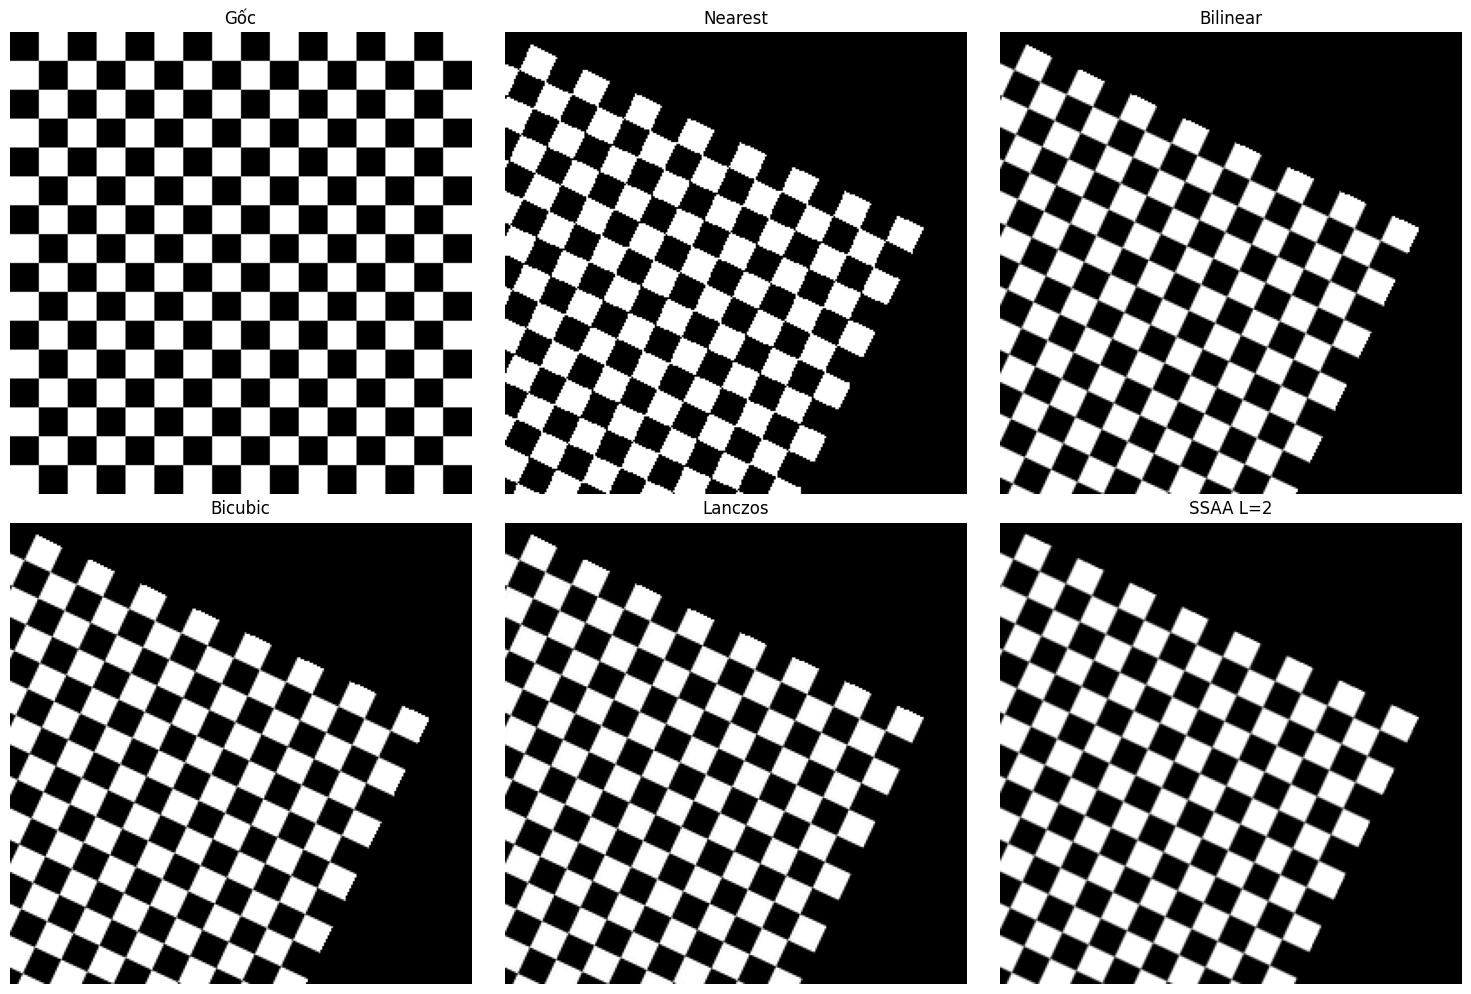

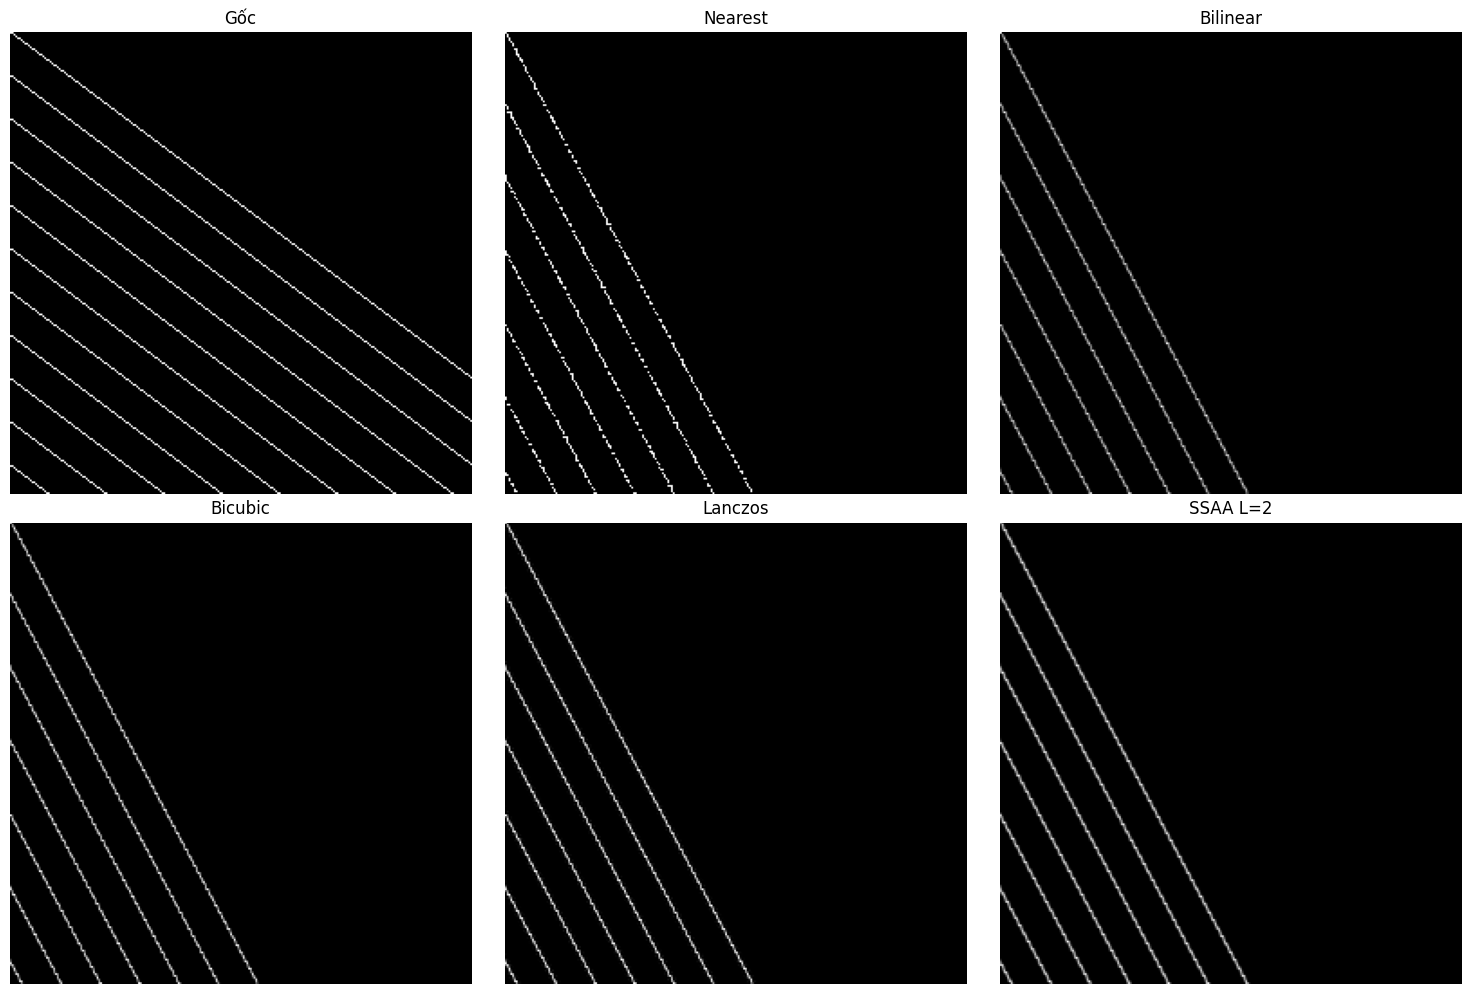

In [49]:
# Ô thực hành so sánh anti-aliasing
# Sau khi hoàn thiện tất cả các hàm, chạy so sánh ở đây.

# Ví dụ khung:
M = rotation_matrix(25)
H, W = checkerboard_img.shape
img_f = checkerboard_img.astype(np.float32)

out_nn  = warp_affine_manual(img_f, M, (H, W), interpolation='nearest')
out_bl  = warp_affine_manual(img_f, M, (H, W), interpolation='bilinear')
out_bc  = warp_affine_manual(img_f, M, (H, W), interpolation='bicubic')
out_lz  = warp_affine_manual(img_f, M, (H, W), interpolation='lanczos')
out_ss  = warp_affine_ssaa(img_f, M, (H, W), L=2)

show_images(
    [checkerboard_img, out_nn, out_bl, out_bc, out_lz, out_ss],
    titles=['Gốc', 'Nearest', 'Bilinear', 'Bicubic', 'Lanczos', 'SSAA L=2'],
    cols=3, figsize=(15, 10)
)

# Thử nghiệm thêm với ảnh đường chéo
H2, W2 = diagonal_img.shape
img_f2 = diagonal_img.astype(np.float32)

out_nn2  = warp_affine_manual(img_f2, M, (H2, W2), interpolation='nearest')
out_bl2  = warp_affine_manual(img_f2, M, (H2, W2), interpolation='bilinear')
out_bc2  = warp_affine_manual(img_f2, M, (H2, W2), interpolation='bicubic')
out_lz2  = warp_affine_manual(img_f2, M, (H2, W2), interpolation='lanczos')
out_ss2  = warp_affine_ssaa(img_f2, M, (H2, W2), L=2)

show_images(
    [diagonal_img, out_nn2, out_bl2, out_bc2, out_lz2, out_ss2],
    titles=['Gốc', 'Nearest', 'Bilinear', 'Bicubic', 'Lanczos', 'SSAA L=2'],
    cols=3, figsize=(15, 10)
)

## Nhận xét cho Bài tập 1 - Hình thái học toán học

### Kết quả với phần tử cấu trúc Rectangle 3x3:
- **Erosion (Xói mòn):** Giảm kích thước các vật thể trắng, loại bỏ các điểm nhiễu nhỏ (như các điểm noise rời rạc). Các cạnh của vật thể bị co lại.
- **Dilation (Giãn nở):** Tăng kích thước các vật thể trắng, nối các vùng gần nhau. Các điểm nhiễu nhỏ trở nên lớn hơn.
- **Opening (Erosion + Dilation):** Loại bỏ các vật thể nhỏ và nhiễu, nhưng giữ nguyên kích thước các vật thể lớn. Hiệu quả trong việc làm sạch ảnh.
- **Closing (Dilation + Erosion):** Đóng các lỗ hổng nhỏ bên trong vật thể, nối các vùng gần nhau. Giữ nguyên kích thước vật thể.
- **Gradient (Dilation - Erosion):** Làm nổi bật các biên của vật thể. Chỉ còn lại các đường viền.

### Kết quả với Rectangle 3x7 (ngang):
- **Opening:** Loại bỏ các vật thể có kích thước nhỏ theo chiều ngang. Các đường dọc mảnh bị loại bỏ.
- **Closing:** Nối các vùng theo chiều ngang, điền đầy các khoảng trống ngang.

### Kết quả với Rectangle 7x3 (dọc):
- **Opening:** Loại bỏ các vật thể có kích thước nhỏ theo chiều dọc. Các đường ngang mảnh bị loại bỏ.
- **Closing:** Nối các vùng theo chiều dọc, điền đầy các khoảng trống dọc.

### Kết quả với Cross 5x5:
- **Erosion:** Giảm kích thước nhưng giữ lại các đặc điểm hình chữ thập. Hiệu quả hơn cho các vật thể có dạng đường.
- **Dilation:** Giãn nở theo cả hai hướng ngang và dọc đồng đều.
- **Opening/Closing:** Tương tự như rectangle nhưng có hiệu ứng khác do cấu trúc cross.

### Kết quả với Ellipse 5x5:
- **Erosion/Dilation:** Hiệu ứng mượt mà hơn so với rectangle, phù hợp cho các vật thể có dạng cong hoặc tròn.
- **Opening/Closing:** Giữ lại các đặc điểm cong tốt hơn rectangle.

---

## Nhận xét cho Bài tập 2 - Biến đổi hình học và Anti-aliasing

### 1. Răng cưa (Jaggies):
- **Kỹ thuật mượt nhất:** Lanczos và Bicubic cho đường chéo mượt nhất, ít răng cưa nhất.
- **Kỹ thuật tệ nhất:** Nearest-neighbor cho răng cưa rõ rệt nhất, đường gồ ghề.
- **SSAA (L=2):** Cải thiện đáng kể so với nearest, nhưng vẫn chưa mượt bằng bicubic/lanczos.
- **Bilinear:** Mượt hơn nearest nhưng vẫn có một số răng cưa.

### 2. Độ mờ:
- **Bilinear:** Có làm mờ cạnh sắc, đặc biệt khi phóng to hoặc xoay. Chi tiết bị mất một phần.
- **Bicubic:** Mượt hơn bilinear nhưng vẫn có một độ mờ nhẹ, giữ chi tiết tốt hơn.
- **Lanczos:** Giữ chi tiết sắc nét tốt nhất, nhưng có hiện tượng "halo" (ringing) nhẹ gần các cạnh sắc.
- **Nearest:** Không làm mờ nhưng có răng cưa.
- **SSAA:** Cân bằng giữa mượt và giữ chi tiết, ít halo hơn lanczos.

### 3. Chi phí tính toán (ước lượng số phép nhân cho mỗi pixel đích):
- **Nearest:** ~0 phép nhân (chỉ làm tròn và truy xuất)
- **Bilinear:** ~4 phép nhân (2x2 patch)
- **Bicubic:** ~16 phép nhân (4x4 patch)
- **SSAA (L=2):** ~4 phép nhân (4 mẫu/pixel) + chi phí nội suy bilinear
- **Lanczos (a=3):** ~36 phép nhân (6x6 patch)

### 4. Trường hợp sử dụng:
- **Ảnh y tế:** Bicubic hoặc Lanczos phù hợp nhất vì cần giữ chi tiết biên quan trọng, không được làm mờ quá nhiều. Lanczos có thể gây halo nên bicubic thường an toàn hơn.
- **Ảnh màu tự nhiên:** SSAA hoặc Bilinear thường đủ tốt, cân bằng giữa chất lượng và tốc độ. Lanczos cho chất lượng cao nhất nhưng chi phí tính toán lớn.

# Checklist trước khi nộp bài

**Bài tập 1 -- Hình thái học**
- [] Đã tự viết hàm padding.
- [ ] Đã tự viết hàm tạo phần tử cấu trúc (rectangle, cross, ellipse).
- [ ] Đã tự viết erosion, dilation, opening, closing, gradient.
- [ ] Đã thử trên ảnh nhị phân kiểm thử và ảnh mẫu giảng viên.
- [ ] Đã có phần nhận xét cho từng kết quả hình thái học.

**Bài tập 2 -- Biến đổi hình học và Anti-aliasing**
- [ ] Đã tự viết `convolve2d_manual` bằng vòng lặp (không dùng hàm có sẵn).
- [ ] Đã tự viết `nearest_interpolate` và `bilinear_interpolate`.
- [ ] Đã tự viết `bicubic_interpolate` (cubic_kernel + 4×4 window).
- [ ] Đã tự viết `lanczos_interpolate` (lanczos_kernel + (2a)×(2a) window).
- [ ] Đã tự viết `warp_affine_ssaa` với supersampling.
- [ ] Đã tự viết `warp_affine_manual` tích hợp đủ bốn phương pháp nội suy.
- [ ] Đã so sánh tất cả kỹ thuật trên cùng một phép biến đổi.
- [ ] Đã trả lời đủ bốn câu hỏi nhận xét trong phần so sánh.
- [ ] Đã dùng ảnh mẫu của giảng viên trong bài nộp chính thức.
- [ ] Đã tuân thủ các hàm bị cấm.
